---
createdAt: 2024-04-17
---

# Fractal carpet rotation

イテレーションに回転を伴うカーペットフラクタル
（M3春に向けた研究）

In [3]:
to0[tbl_] := ConstantArray[0, Dimensions[tbl]]
nop[tbl_] := tbl
rl[tbl_] := Reverse[Transpose[tbl]]
rr[tbl_] := Transpose[Reverse[tbl]]
ro[tbl_] := rr[rr[tbl]]

{Identity, Reverse, Transpose, Reverse @* Transpose, Transpose @* Reverse, 
 
>   Reverse @* Transpose @* Reverse, Transpose @* Reverse @* Transpose, 
 
>   Reverse @* Transpose @* Reverse @* Transpose}
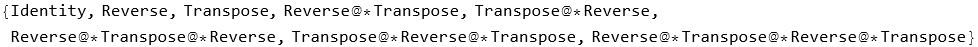

In [8]:
opLi = DeleteDuplicatesBy[Composition @@@ Tuples[{Identity, Reverse, Transpose}, 4], # @ Partition[Range[4], 2] &]

{0   0   0, 1   2   3, 3   6   9, 7   4   1, 9   8   7}

 0   0   0  4   5   6  2   5   8  8   5   2  6   5   4

 0   0   0  7   8   9  1   4   7  9   6   3  3   2   1
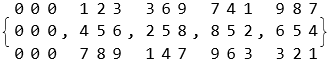

In [9]:
Grid[#[{{1, 2, 3}, {4, 5, 6}, {7, 8, 9}}]] & /@ {to0, nop, rl, rr, ro}

{-Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, 
 
>   -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, 
 
>   -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, 
 
>   -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, 
 
>   -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, 
 
>   -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, 
 
>   -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, 
 
>   -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, 
 
>   -Graphics-, -Graphics-, -Graphics-, -Graphics-}
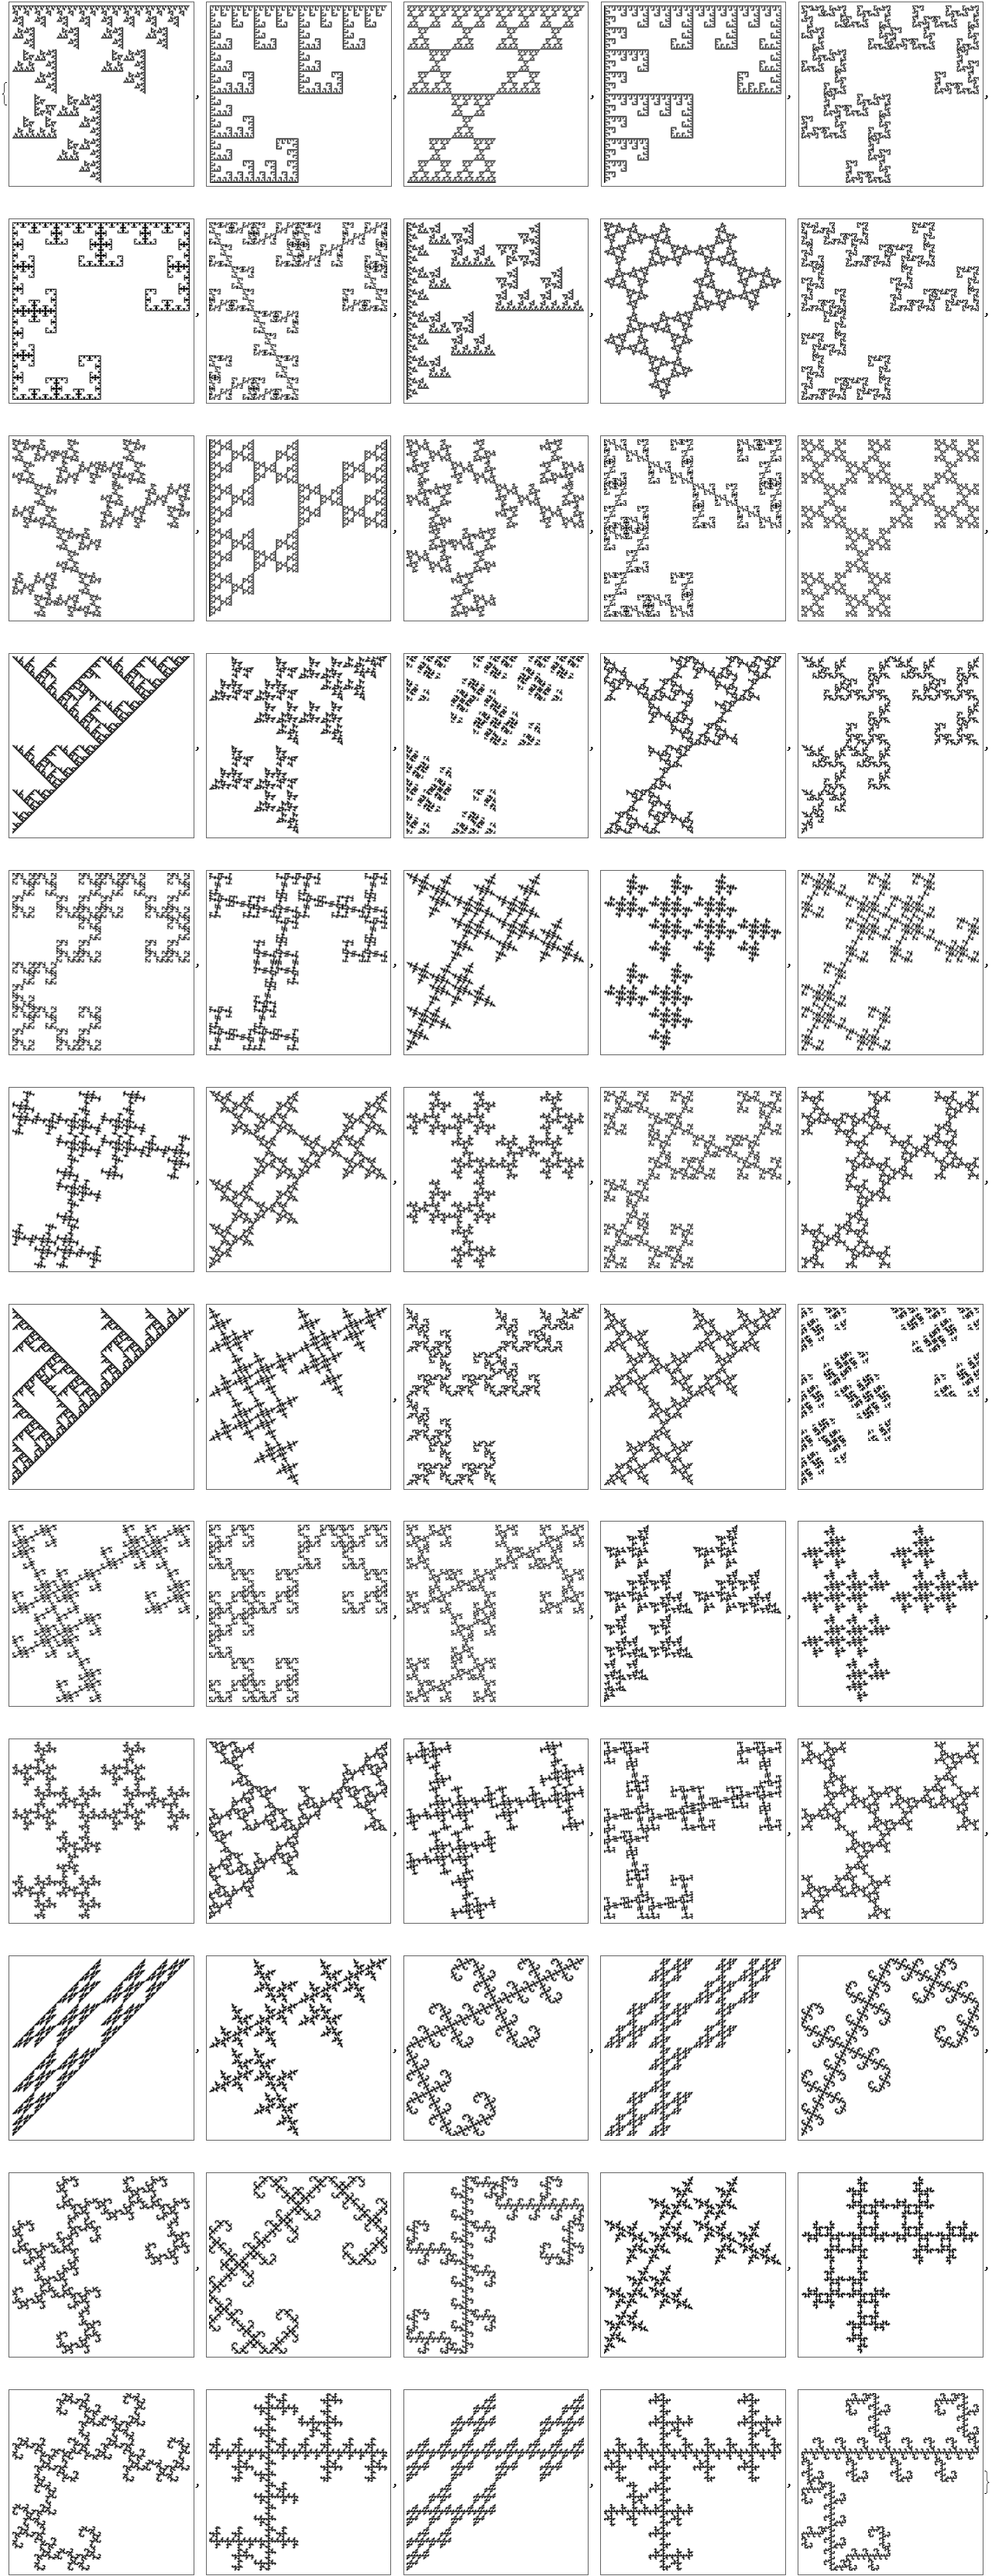

In [10]:
ArrayPlot /@ Table[Nest[ArrayFlatten[Comap[Partition[mapTbl, 2], #, {2}]] &, {{1}}, 8], {mapTbl, Select[Tuples[{to0, nop, rr, rl, ro}, 4], Count[#, to0] == 1 && Length[Union[#]] >= 3 && Last[#] == to0 &]}]

正方形4分割のうち、右下のみ空白で、「何もしない」以外に左右90度回転と180回転の演算を1つ以上含むイテレーションを行った結果が対称的でないものは以下の27通り

{-Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, 
 
>   -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, 
 
>   -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, 
 
>   -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-}
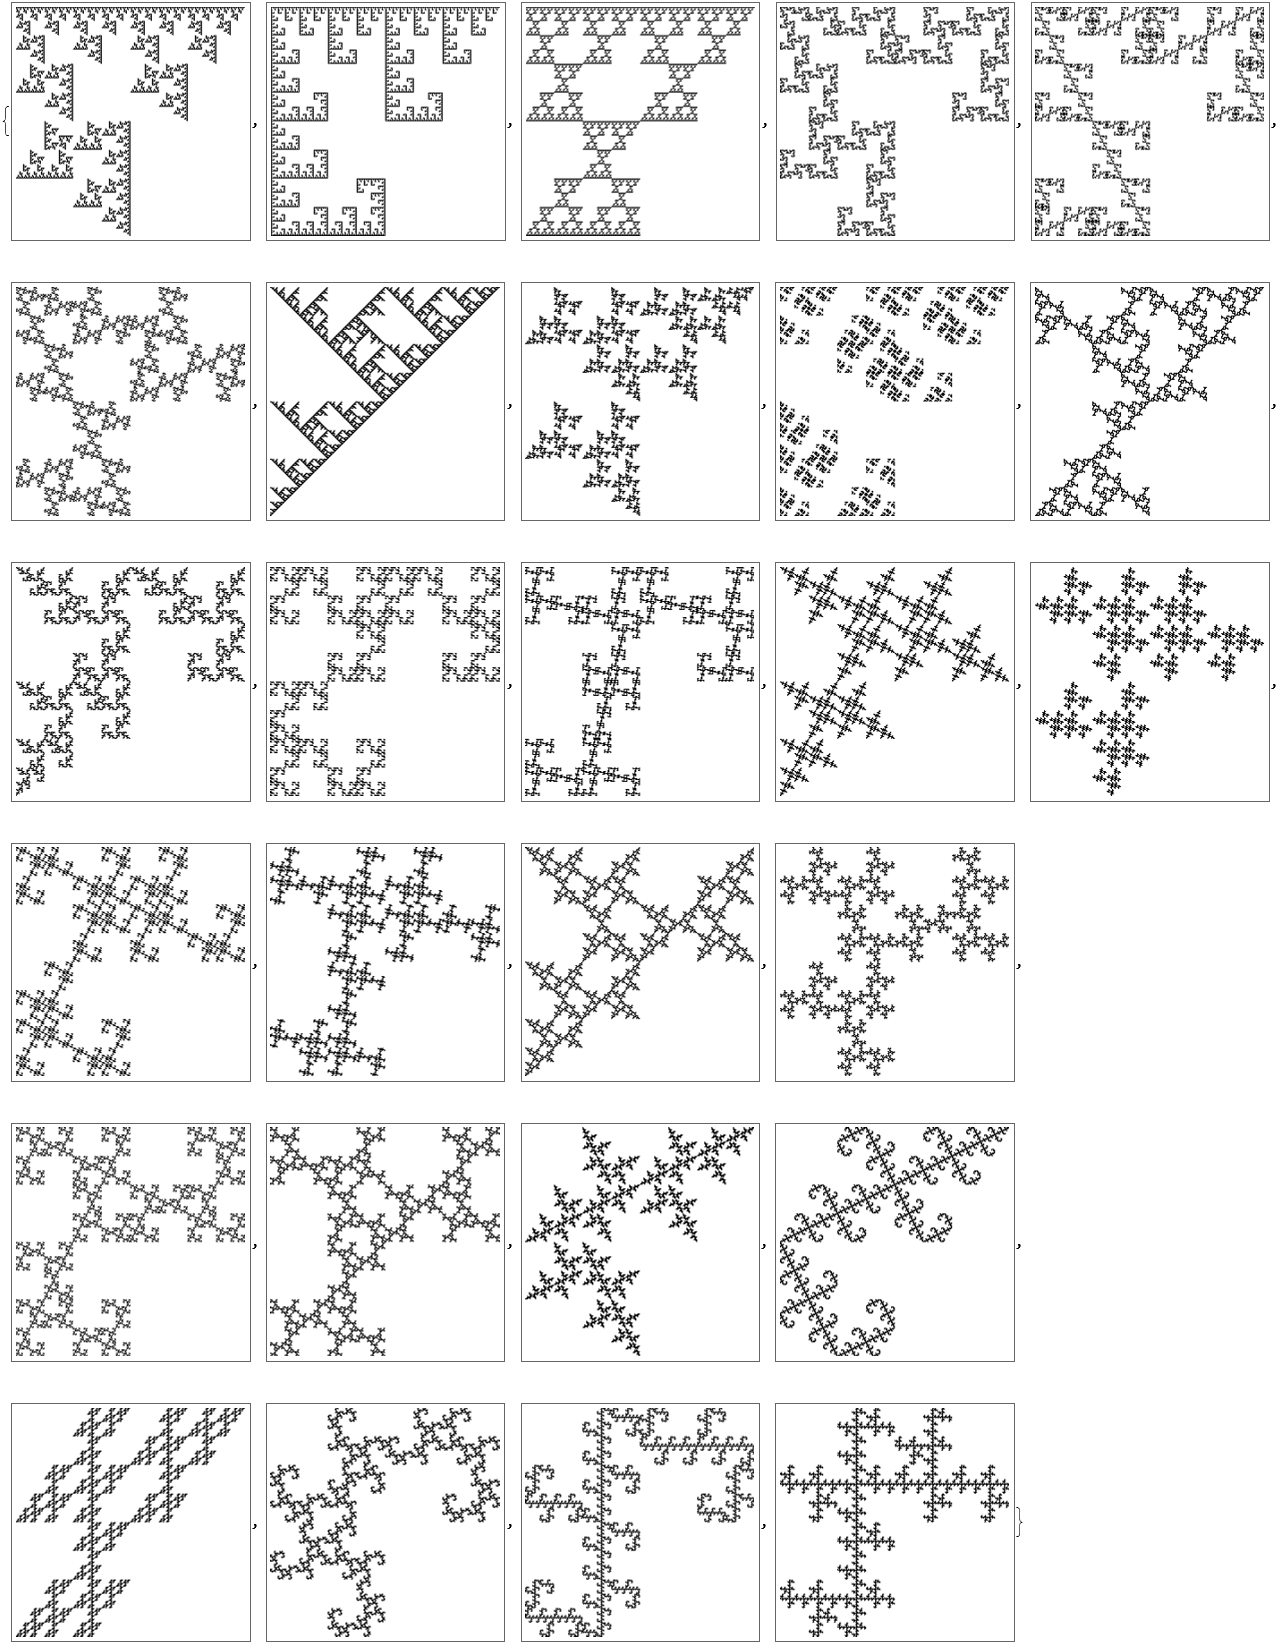

In [11]:
ArrayPlot /@ Select[DeleteDuplicatesBy[Table[Nest[ArrayFlatten[Comap[Partition[mapTbl, 2], #, {2}]] &, {{1}}, 8], {mapTbl, Select[Tuples[{to0, nop, rr, rl, ro}, 4], Count[#, to0] == 1 && Length[Union[#]] >= 3 && Last[#] == to0 &]}], Union[Table[op[#], {op, opLi}]] &], Length[Union[Table[op[#], {op, opLi}]]] == Length[opLi] &]

対称形6パターン

{-Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-, -Graphics-}
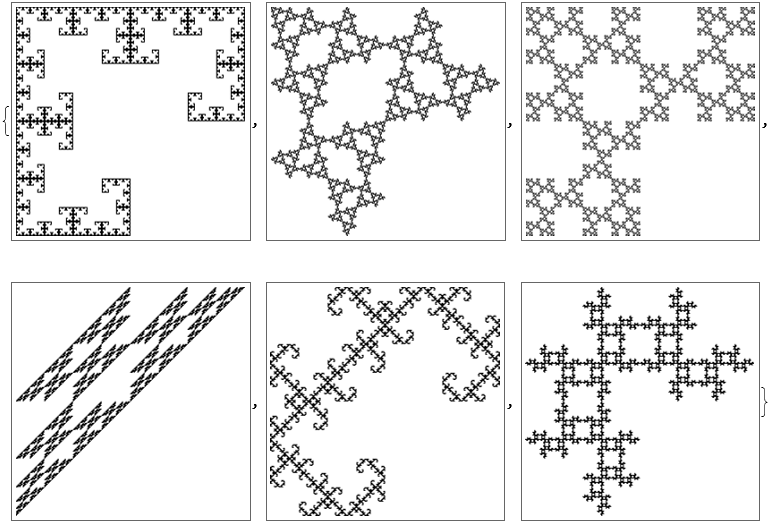

In [12]:
ArrayPlot /@ Select[DeleteDuplicatesBy[Table[Nest[ArrayFlatten[Comap[Partition[mapTbl, 2], #, {2}]] &, {{1}}, 8], {mapTbl, Select[Tuples[{to0, nop, rr, rl, ro}, 4], Count[#, to0] == 1 && Length[Union[#]] >= 3 && Last[#] == to0 &]}], Union[Table[op[#], {op, opLi}]] &], Length[Union[Table[op[#], {op, opLi}]]] != Length[opLi] &]